<a href="https://www.kaggle.com/code/omborse771924/enhanced-breast-cancer-diagnostic-dataset-eda?scriptVersionId=328962849" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/shivasingh4945/enhanced-breast-cancer-diagnostic-dataset/breast_cancer_enhanced_dataset.csv


## Loading Dataset

In [2]:
df = pd.read_csv('/kaggle/input/datasets/shivasingh4945/enhanced-breast-cancer-diagnostic-dataset/breast_cancer_enhanced_dataset.csv')

In [3]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,shape_irregularity,border_complexity,tumor_aggressiveness,radius_texture_interaction,radius_concavity_interaction,concavity_density,malignancy_risk_score
0,5.683796e+06,B,11.829858,21.726166,75.154378,435.022394,0.087089,0.050717,0.015868,0.011641,0.078226,0.000185,0.026075,257.017451,0.187718,0.000036,22.433798
1,-6.253379e+06,B,10.991150,17.103260,71.798929,381.386295,0.089339,0.109498,0.097344,0.035629,0.242470,0.003468,0.080823,187.984489,1.069921,0.000255,24.021839
2,4.213892e+06,M,21.433519,15.092437,142.753006,1392.399890,0.099557,0.152079,0.193372,0.126922,0.472373,0.024543,0.157458,323.484034,4.144647,0.000139,49.053992
3,-2.986069e+06,B,11.700452,14.872127,74.154481,404.112556,0.101291,0.077563,0.043749,0.028747,0.150059,0.001258,0.050020,174.010599,0.511885,0.000108,23.276145
4,6.469594e+05,B,13.259377,17.212990,83.621014,521.124238,0.072905,0.043312,0.046983,0.010096,0.100391,0.000474,0.033464,228.233523,0.622960,0.000090,25.647074


In [4]:
df.tail()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,shape_irregularity,border_complexity,tumor_aggressiveness,radius_texture_interaction,radius_concavity_interaction,concavity_density,malignancy_risk_score
5495,2.909607e+06,B,11.688492,18.217548,75.277156,429.895271,0.113777,0.104274,0.069515,0.034620,0.208409,0.002407,0.069470,212.935657,0.812528,0.000162,24.344788
5496,4.399236e+05,B,13.831066,19.454900,88.204429,580.072530,0.087240,0.061584,0.012322,0.022518,0.096424,0.000277,0.032141,269.082007,0.170427,0.000021,26.379882
5497,-4.461865e+06,M,19.403923,18.152520,127.631265,1129.627896,0.104142,0.144262,0.164108,0.094511,0.402881,0.015510,0.134294,352.230108,3.184337,0.000145,43.224263
5498,7.519916e+06,M,20.946319,25.233666,142.498720,1340.103257,0.109454,0.226277,0.316075,0.148336,0.690688,0.046885,0.230229,528.552405,6.620608,0.000236,52.471548
5499,-3.163711e+06,M,19.936731,22.043719,129.216656,1269.726727,0.098140,0.102896,0.146180,0.096857,0.345933,0.014159,0.115311,439.479696,2.914349,0.000115,43.364274


In [5]:
df.describe

<bound method NDFrame.describe of                 id diagnosis  radius_mean  texture_mean  perimeter_mean  \
0     5.683796e+06         B    11.829858     21.726166       75.154378   
1    -6.253379e+06         B    10.991150     17.103260       71.798929   
2     4.213892e+06         M    21.433519     15.092437      142.753006   
3    -2.986069e+06         B    11.700452     14.872127       74.154481   
4     6.469594e+05         B    13.259377     17.212990       83.621014   
...            ...       ...          ...           ...             ...   
5495  2.909607e+06         B    11.688492     18.217548       75.277156   
5496  4.399236e+05         B    13.831066     19.454900       88.204429   
5497 -4.461865e+06         M    19.403923     18.152520      127.631265   
5498  7.519916e+06         M    20.946319     25.233666      142.498720   
5499 -3.163711e+06         M    19.936731     22.043719      129.216656   

        area_mean  smoothness_mean  compactness_mean  concavity_m

In [6]:
df.isnull

<bound method DataFrame.isnull of                 id diagnosis  radius_mean  texture_mean  perimeter_mean  \
0     5.683796e+06         B    11.829858     21.726166       75.154378   
1    -6.253379e+06         B    10.991150     17.103260       71.798929   
2     4.213892e+06         M    21.433519     15.092437      142.753006   
3    -2.986069e+06         B    11.700452     14.872127       74.154481   
4     6.469594e+05         B    13.259377     17.212990       83.621014   
...            ...       ...          ...           ...             ...   
5495  2.909607e+06         B    11.688492     18.217548       75.277156   
5496  4.399236e+05         B    13.831066     19.454900       88.204429   
5497 -4.461865e+06         M    19.403923     18.152520      127.631265   
5498  7.519916e+06         M    20.946319     25.233666      142.498720   
5499 -3.163711e+06         M    19.936731     22.043719      129.216656   

        area_mean  smoothness_mean  compactness_mean  concavity_m

In [7]:
df.isnull().sum()

id                              0
diagnosis                       0
radius_mean                     0
texture_mean                    0
perimeter_mean                  0
area_mean                       0
smoothness_mean                 0
compactness_mean                0
concavity_mean                  0
concave points_mean             0
shape_irregularity              0
border_complexity               0
tumor_aggressiveness            0
radius_texture_interaction      0
radius_concavity_interaction    0
concavity_density               0
malignancy_risk_score           0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'shape_irregularity', 'border_complexity',
       'tumor_aggressiveness', 'radius_texture_interaction',
       'radius_concavity_interaction', 'concavity_density',
       'malignancy_risk_score'],
      dtype='object')

## EDA

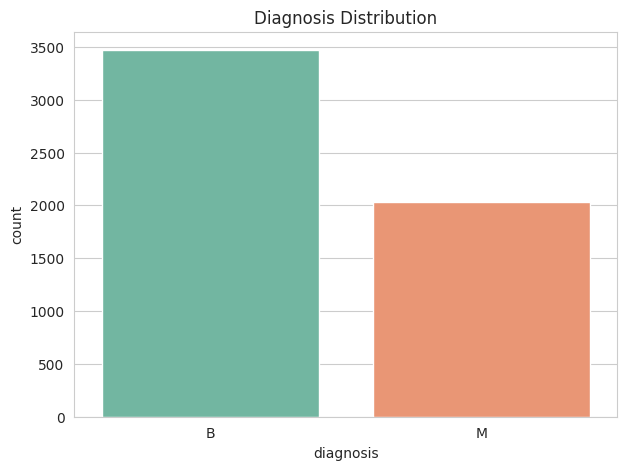

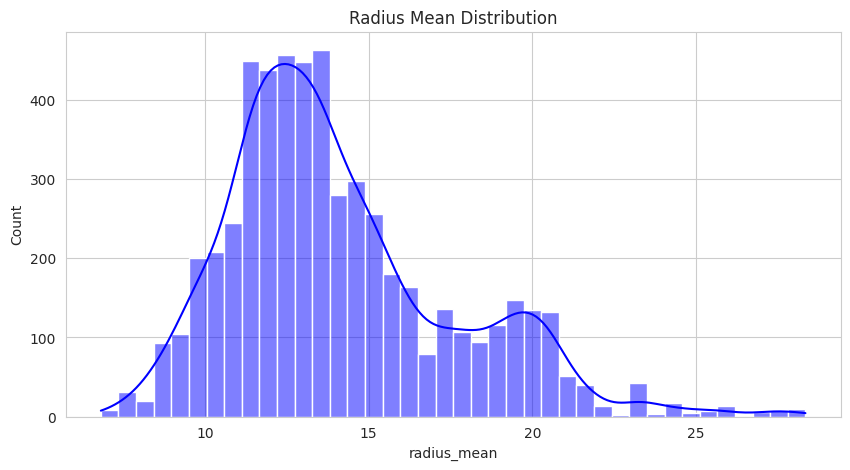

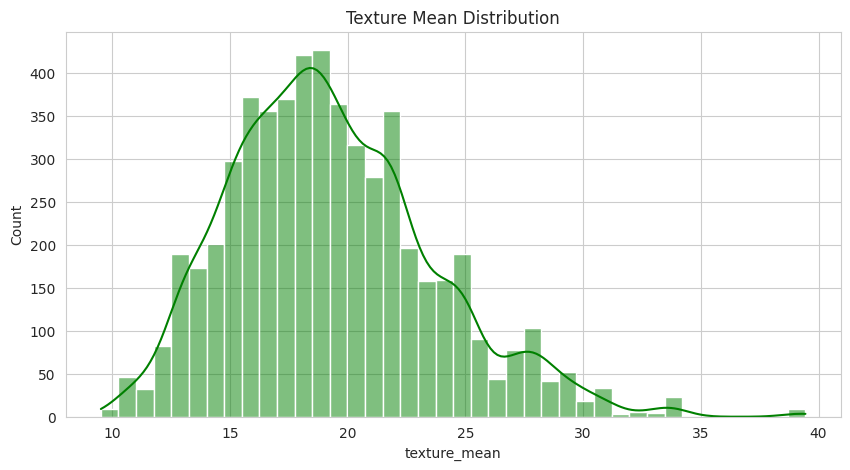

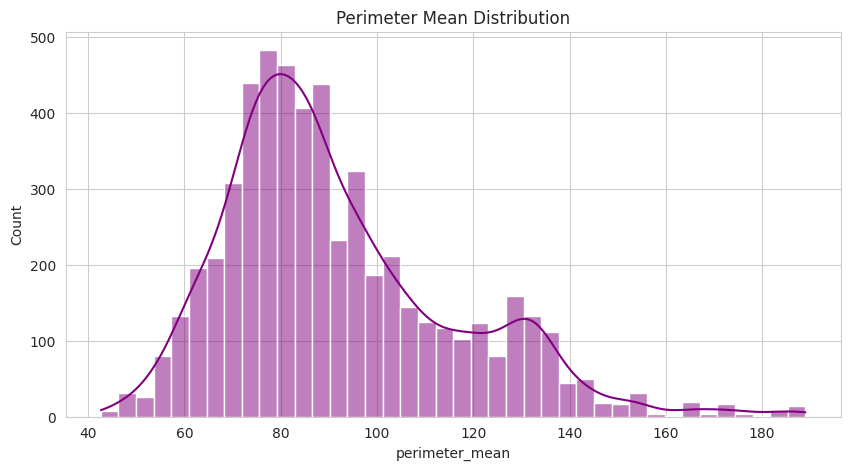

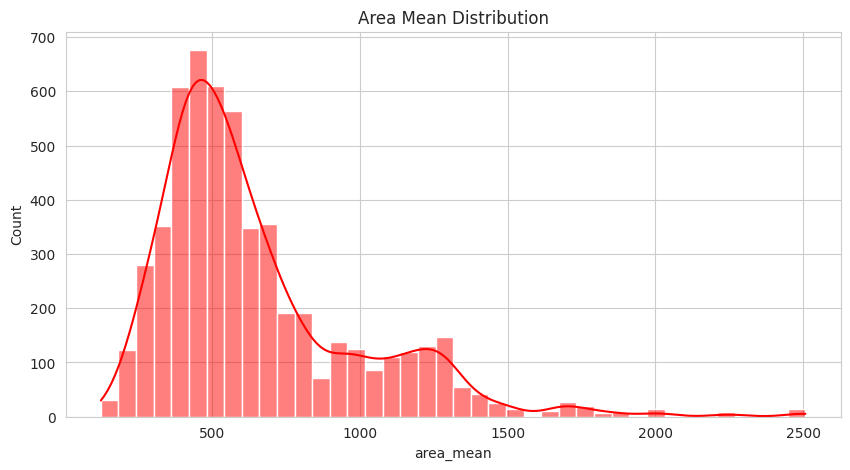

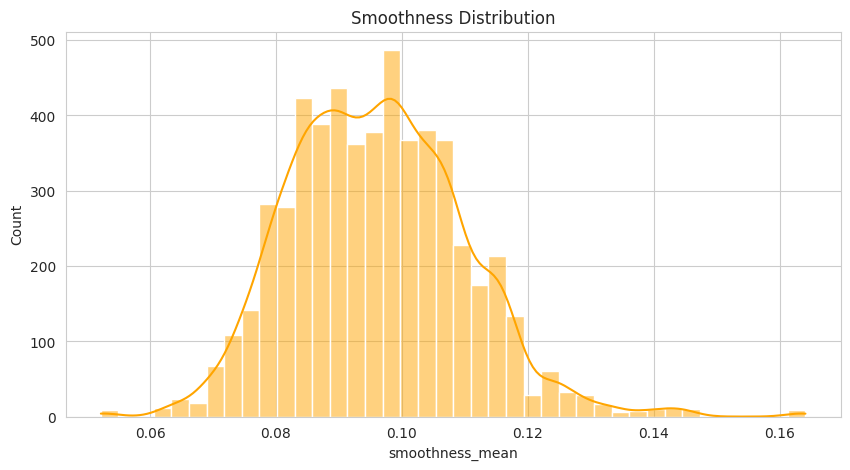

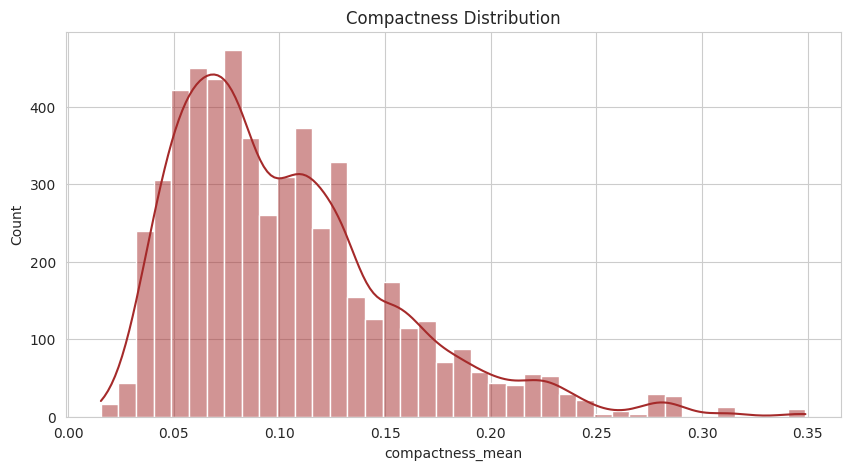

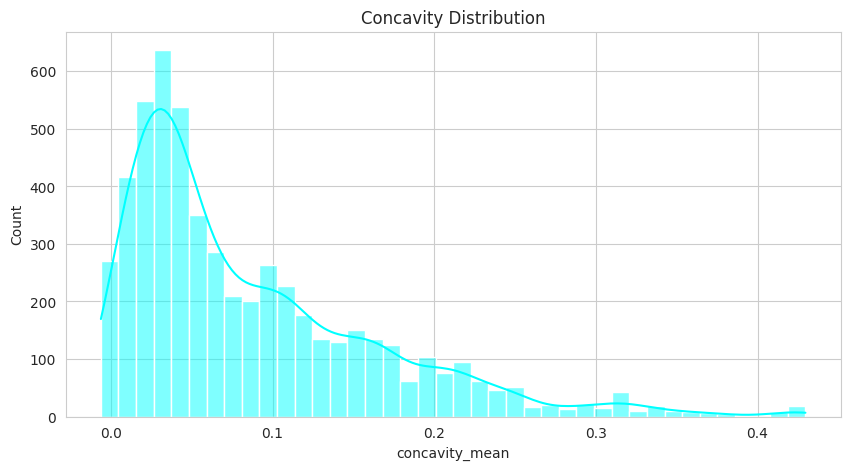

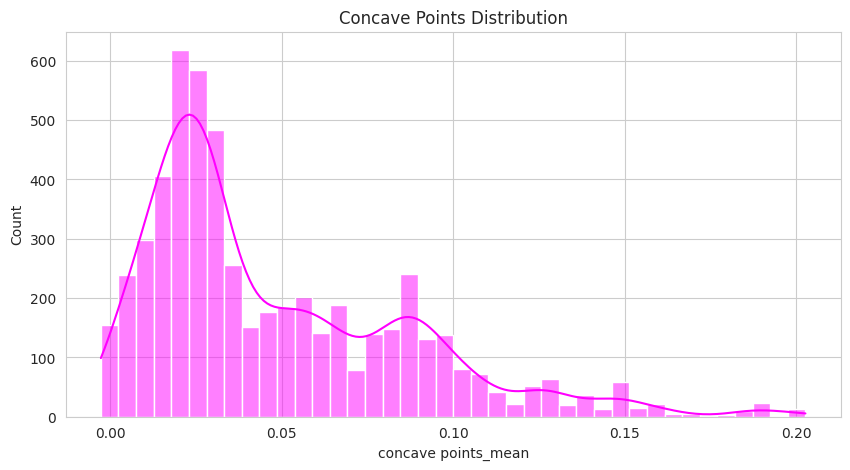

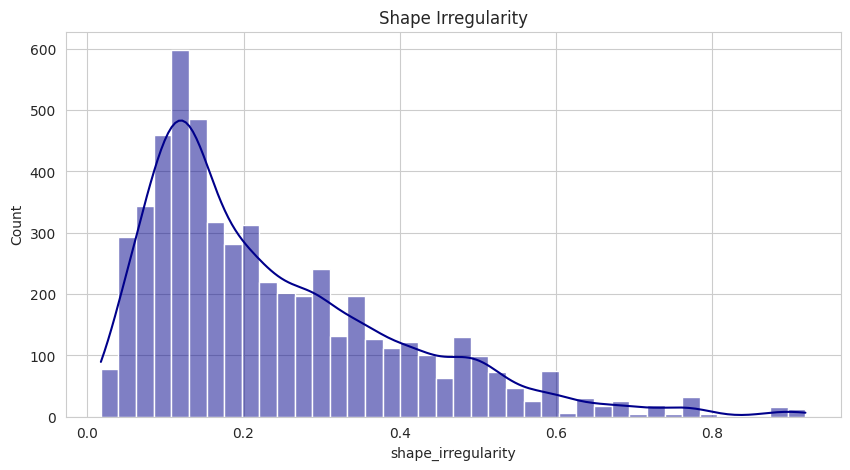

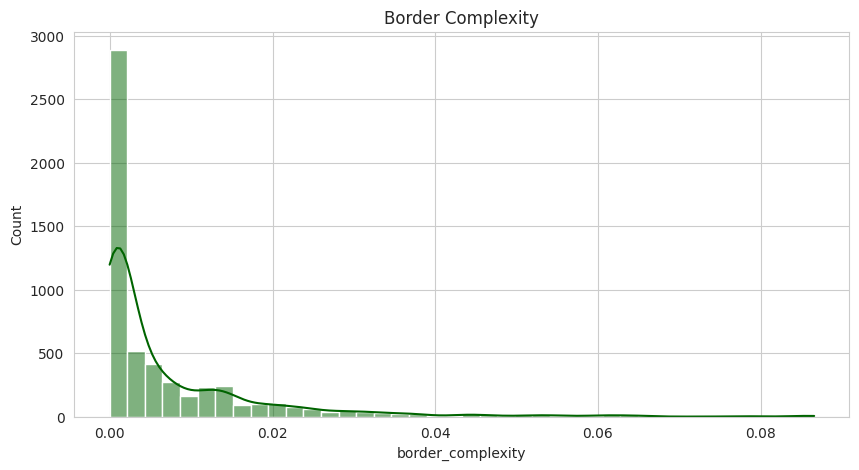

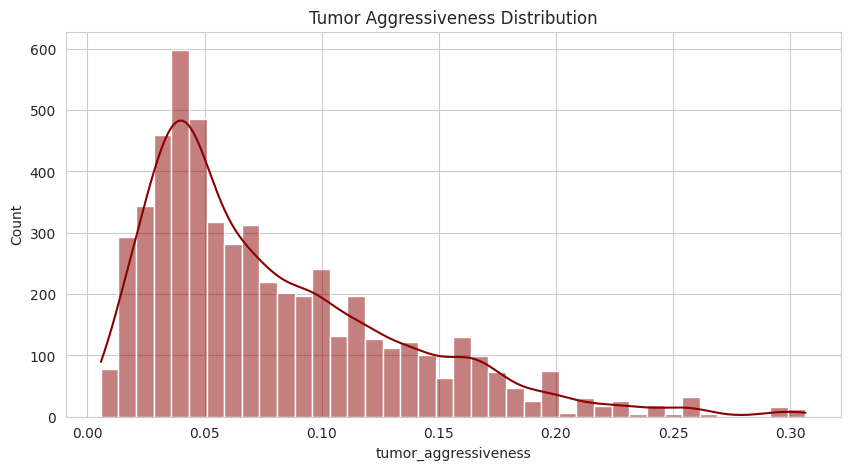

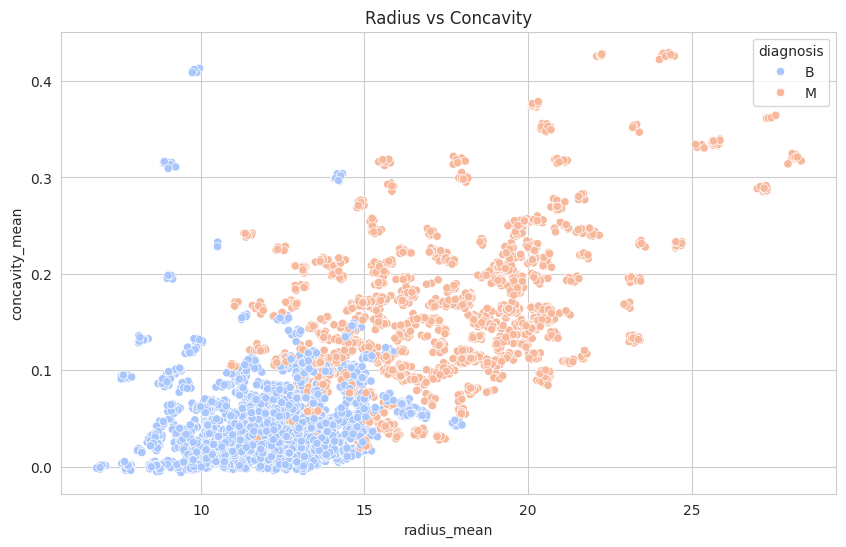

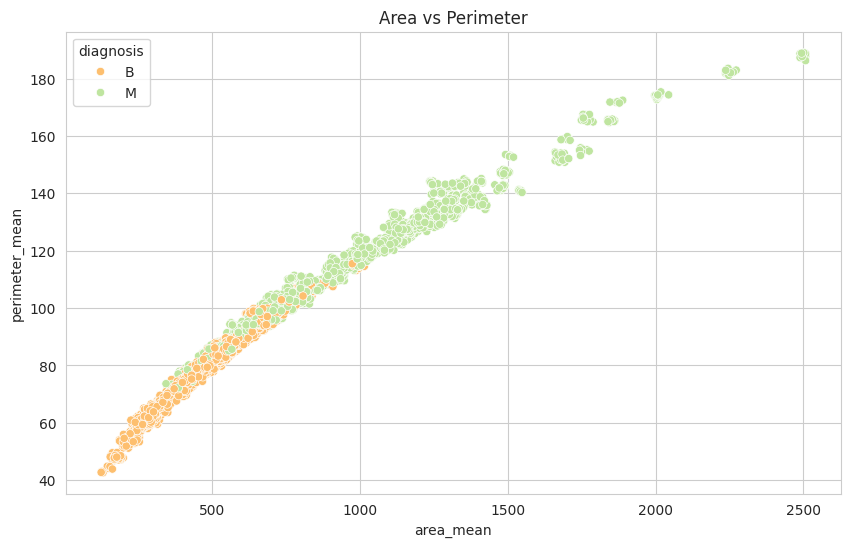

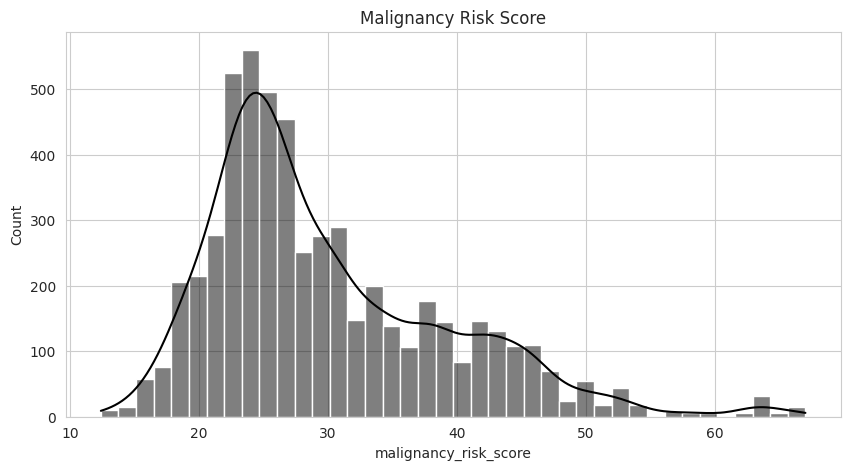

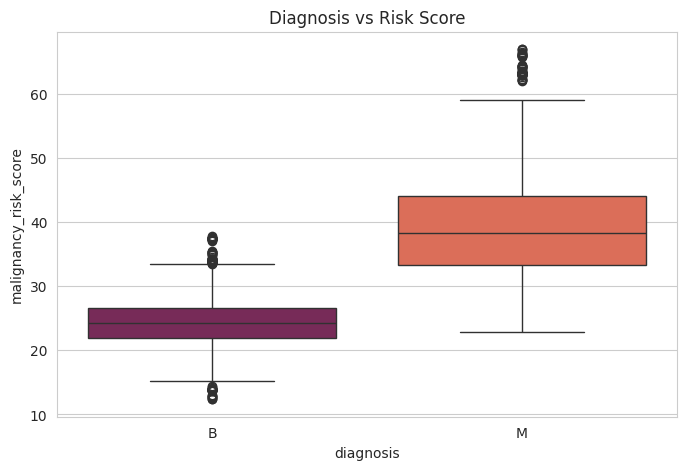

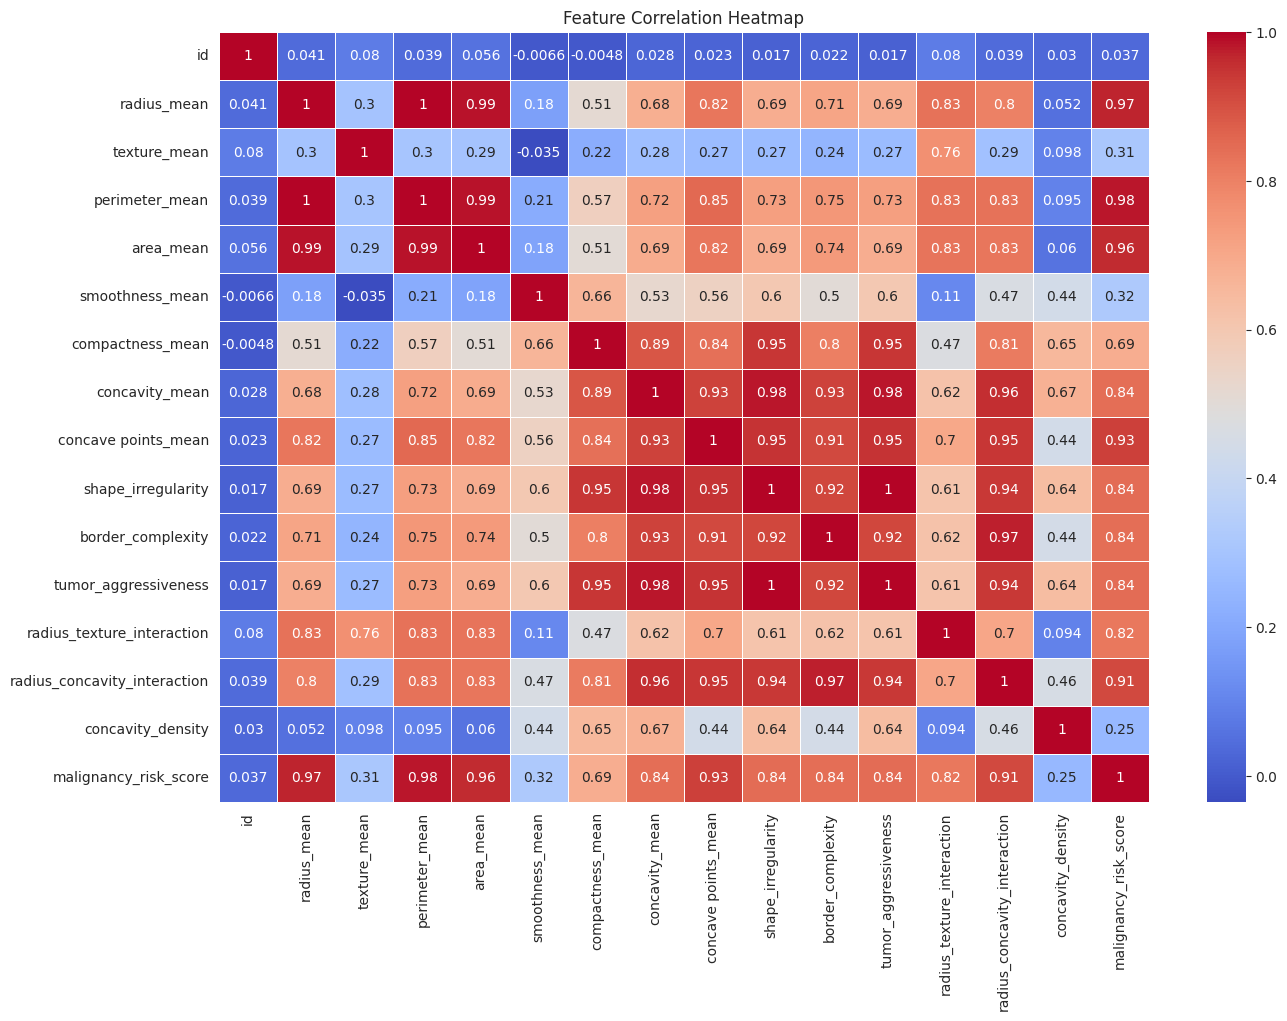

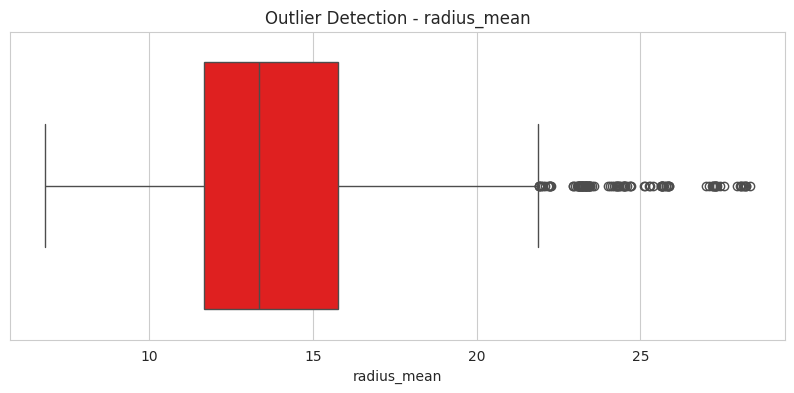

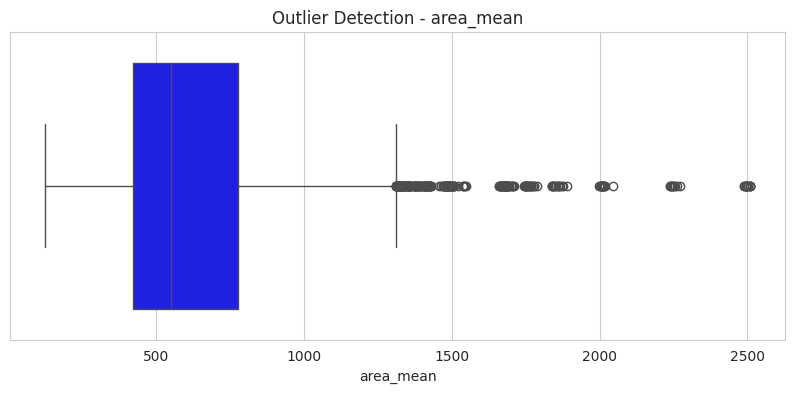

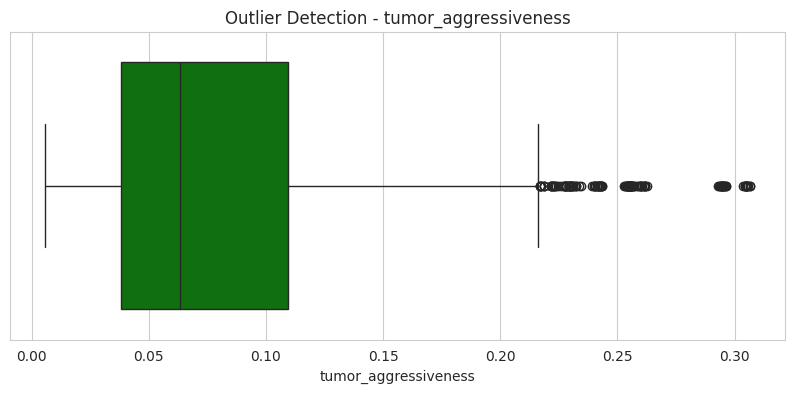

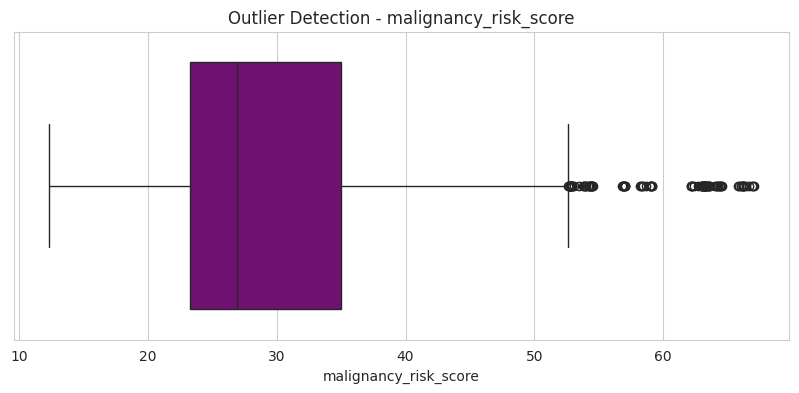

Breast Cancer Visualization Completed Successfully!


In [10]:
sns.set_style("whitegrid")

# ============================================================
# 1. DIAGNOSIS DISTRIBUTION
# ============================================================


plt.figure(figsize=(7,5))


sns.countplot(

data=df,

x="diagnosis",

hue="diagnosis",

palette="Set2",

legend=False

)



plt.title(
"Diagnosis Distribution"
)


plt.show()









# ============================================================
# 2. RADIUS MEAN
# ============================================================


plt.figure(figsize=(10,5))


sns.histplot(

df["radius_mean"],

bins=40,

kde=True,

color="blue"

)



plt.title(
"Radius Mean Distribution"
)


plt.show()









# ============================================================
# 3. TEXTURE MEAN
# ============================================================


plt.figure(figsize=(10,5))


sns.histplot(

df["texture_mean"],

bins=40,

kde=True,

color="green"

)



plt.title(
"Texture Mean Distribution"
)


plt.show()









# ============================================================
# 4. PERIMETER MEAN
# ============================================================


plt.figure(figsize=(10,5))


sns.histplot(

df["perimeter_mean"],

bins=40,

kde=True,

color="purple"

)


plt.title(
"Perimeter Mean Distribution"
)


plt.show()










# ============================================================
# 5. AREA MEAN
# ============================================================


plt.figure(figsize=(10,5))


sns.histplot(

df["area_mean"],

bins=40,

kde=True,

color="red"

)


plt.title(
"Area Mean Distribution"
)


plt.show()







# ============================================================
# 6. SMOOTHNESS
# ============================================================


plt.figure(figsize=(10,5))


sns.histplot(

df["smoothness_mean"],

bins=40,

kde=True,

color="orange"

)


plt.title(
"Smoothness Distribution"
)


plt.show()








# ============================================================
# 7. COMPACTNESS
# ============================================================


plt.figure(figsize=(10,5))


sns.histplot(

df["compactness_mean"],

bins=40,

kde=True,

color="brown"

)


plt.title(
"Compactness Distribution"
)


plt.show()








# ============================================================
# 8. CONCAVITY
# ============================================================


plt.figure(figsize=(10,5))


sns.histplot(

df["concavity_mean"],

bins=40,

kde=True,

color="cyan"

)


plt.title(
"Concavity Distribution"
)


plt.show()








# ============================================================
# 9. CONCAVE POINTS
# ============================================================


plt.figure(figsize=(10,5))


sns.histplot(

df["concave points_mean"],

bins=40,

kde=True,

color="magenta"

)


plt.title(
"Concave Points Distribution"
)


plt.show()







# ============================================================
# 10. SHAPE IRREGULARITY
# ============================================================


plt.figure(figsize=(10,5))


sns.histplot(

df["shape_irregularity"],

bins=40,

kde=True,

color="darkblue"

)


plt.title(
"Shape Irregularity"
)


plt.show()








# ============================================================
# 11. BORDER COMPLEXITY
# ============================================================


plt.figure(figsize=(10,5))


sns.histplot(

df["border_complexity"],

bins=40,

kde=True,

color="darkgreen"

)


plt.title(
"Border Complexity"
)


plt.show()








# ============================================================
# 12. TUMOR AGGRESSIVENESS
# ============================================================


plt.figure(figsize=(10,5))


sns.histplot(

df["tumor_aggressiveness"],

bins=40,

kde=True,

color="darkred"

)



plt.title(
"Tumor Aggressiveness Distribution"
)


plt.show()









# ============================================================
# 13. RADIUS VS CONCAVITY
# ============================================================


plt.figure(figsize=(10,6))


sns.scatterplot(

data=df,

x="radius_mean",

y="concavity_mean",

hue="diagnosis",

palette="coolwarm"

)


plt.title(
"Radius vs Concavity"
)


plt.show()









# ============================================================
# 14. AREA VS PERIMETER
# ============================================================


plt.figure(figsize=(10,6))


sns.scatterplot(

data=df,

x="area_mean",

y="perimeter_mean",

hue="diagnosis",

palette="Spectral"

)


plt.title(
"Area vs Perimeter"
)


plt.show()







# ============================================================
# 15. RISK SCORE ANALYSIS
# ============================================================


plt.figure(figsize=(10,5))


sns.histplot(

df["malignancy_risk_score"],

bins=40,

kde=True,

color="black"

)



plt.title(
"Malignancy Risk Score"
)


plt.show()








# ============================================================
# 16. DIAGNOSIS VS RISK
# ============================================================


plt.figure(figsize=(8,5))


sns.boxplot(

data=df,

x="diagnosis",

y="malignancy_risk_score",

hue="diagnosis",

palette="rocket",

legend=False

)


plt.title(
"Diagnosis vs Risk Score"
)


plt.show()









# ============================================================
# 17. FEATURE CORRELATION
# ============================================================


numeric=df.select_dtypes(
include=np.number
)



plt.figure(figsize=(15,10))


sns.heatmap(

numeric.corr(),

annot=True,

cmap="coolwarm",

linewidth=0.5

)


plt.title(
"Feature Correlation Heatmap"
)


plt.show()








# ============================================================
# 18. OUTLIER DETECTION
# ============================================================


features=[

"radius_mean",

"area_mean",

"tumor_aggressiveness",

"malignancy_risk_score"

]



colors=[

"red",

"blue",

"green",

"purple"

]




for feature,color in zip(features,colors):


    plt.figure(figsize=(10,4))


    sns.boxplot(

        x=df[feature],

        color=color

    )



    plt.title(
        f"Outlier Detection - {feature}"
    )



    plt.show()





print(
"Breast Cancer Visualization Completed Successfully!"
)

## Features Engineering

['B' 'M']

Logistic Regression
Accuracy: 0.9318
              precision    recall  f1-score   support

           0       0.94      0.96      0.95       694
           1       0.92      0.89      0.91       406

    accuracy                           0.93      1100
   macro avg       0.93      0.92      0.93      1100
weighted avg       0.93      0.93      0.93      1100


Decision Tree
Accuracy: 0.9891
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       694
           1       0.99      0.98      0.99       406

    accuracy                           0.99      1100
   macro avg       0.99      0.99      0.99      1100
weighted avg       0.99      0.99      0.99      1100


Random Forest
Accuracy: 0.9936
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       694
           1       1.00      0.99      0.99       406

    accuracy                           0.99      1100
   macro avg    

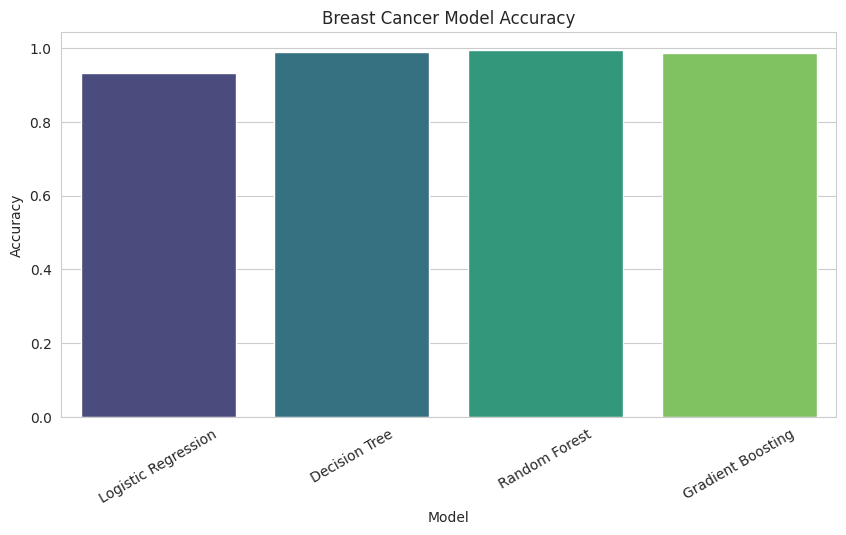

BEST MODEL: Random Forest


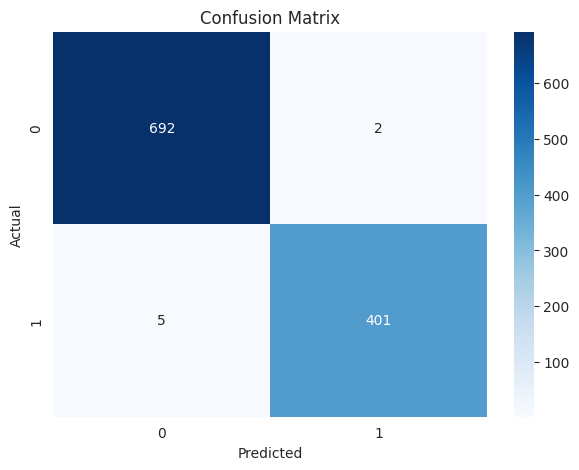

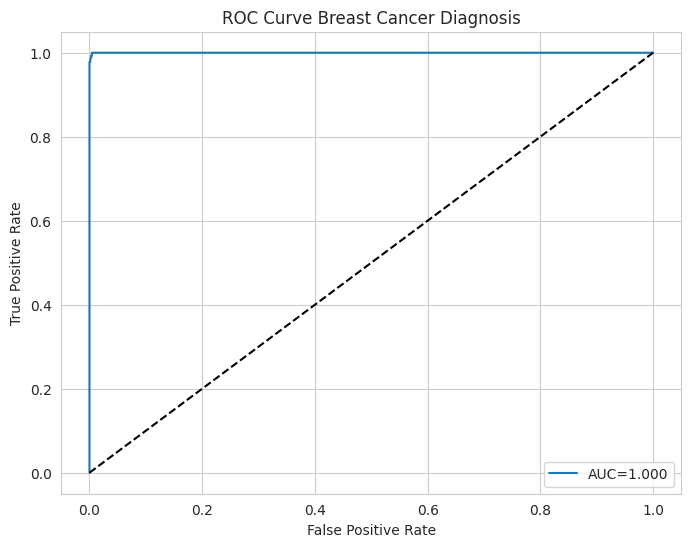

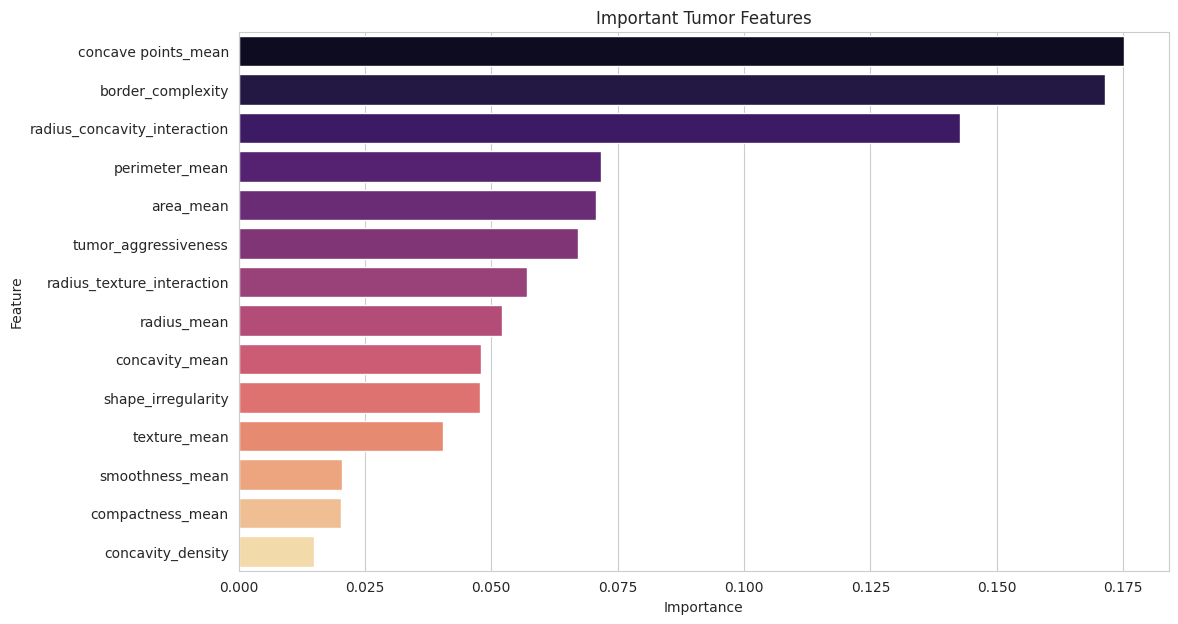


FINAL RESULT
Logistic Regression : 0.9318
Decision Tree : 0.9891
Random Forest : 0.9936
Gradient Boosting : 0.9864
BEST MODEL: Random Forest
BEST ACCURACY: 0.9936


In [11]:
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import (
    StandardScaler,
    LabelEncoder
)


from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer


from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier


from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)


from sklearn.metrics import (

    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score

)

# ============================================================
# TARGET
# ============================================================


target="diagnosis"



X=df.drop(

    target,

    axis=1

)



y=df[target]










# ============================================================
# REMOVE LEAKAGE / USELESS COLUMNS
# ============================================================


drop_cols=[


"id",


# direct calculated risk score can leak diagnosis

"malignancy_risk_score"



]




X=X.drop(

columns=drop_cols,

errors="ignore"

)









# ============================================================
# ENCODE TARGET ONLY
# ============================================================

encoder=LabelEncoder()


y=encoder.fit_transform(
    y
)



print(
encoder.classes_
)











# ============================================================
# TRAIN TEST SPLIT FIRST
# ============================================================


X_train,X_test,y_train,y_test=train_test_split(

    X,

    y,


    test_size=0.2,


    random_state=42,


    stratify=y

)









# ============================================================
# PREPROCESSING PIPELINE
# ============================================================


preprocess=Pipeline(

steps=[



(

"imputer",

SimpleImputer(
strategy="median"
)

),




(

"scaler",

StandardScaler()

)



]

)










# ============================================================
# MODELS
# ============================================================


models={



"Logistic Regression":

LogisticRegression(
max_iter=1000
),




"Decision Tree":

DecisionTreeClassifier(
random_state=42
),




"Random Forest":

RandomForestClassifier(

n_estimators=200,

random_state=42,

n_jobs=-1

),





"Gradient Boosting":

GradientBoostingClassifier(

random_state=42

)


}









results={}

trained={}









# ============================================================
# TRAIN MODELS
# ============================================================


for name,model in models.items():


    print("\n====================")

    print(name)

    print("====================")





    pipeline=Pipeline(

    steps=[



    (

    "preprocess",

    preprocess

    ),




    (

    "model",

    model

    )



    ]

    )









    pipeline.fit(

        X_train,

        y_train

    )







    prediction=pipeline.predict(

        X_test

    )








    acc=accuracy_score(

        y_test,

        prediction

    )






    results[name]=acc


    trained[name]=pipeline








    print(

    "Accuracy:",

    round(acc,4)

    )





    print(

    classification_report(

    y_test,

    prediction

    )

    )











# ============================================================
# MODEL ACCURACY COMPARISON
# ============================================================


accuracy_df=pd.DataFrame({

"Model":list(results.keys()),

"Accuracy":list(results.values())

})






plt.figure(figsize=(10,5))


sns.barplot(

data=accuracy_df,

x="Model",

y="Accuracy",

hue="Model",

palette="viridis",

legend=False

)



plt.title(
"Breast Cancer Model Accuracy"
)


plt.xticks(rotation=30)


plt.show()











# ============================================================
# BEST MODEL
# ============================================================


best_name=max(

results,

key=results.get

)



best_model=trained[
best_name
]





print(

"BEST MODEL:",

best_name

)











# ============================================================
# CONFUSION MATRIX
# ============================================================


best_pred=best_model.predict(

X_test

)





plt.figure(figsize=(7,5))


sns.heatmap(

confusion_matrix(

y_test,

best_pred

),

annot=True,

fmt="d",

cmap="Blues"

)



plt.title(
"Confusion Matrix"
)



plt.xlabel(
"Predicted"
)


plt.ylabel(
"Actual"
)



plt.show()










# ============================================================
# ROC CURVE
# ============================================================


prob=best_model.predict_proba(

X_test

)[:,1]





fpr,tpr,_=roc_curve(

y_test,

prob

)



auc=roc_auc_score(

y_test,

prob

)








plt.figure(figsize=(8,6))


plt.plot(

fpr,

tpr,

label=f"AUC={auc:.3f}"

)




plt.plot(

[0,1],

[0,1],

"k--"

)





plt.xlabel(

"False Positive Rate"

)



plt.ylabel(

"True Positive Rate"

)



plt.title(

"ROC Curve Breast Cancer Diagnosis"

)



plt.legend()


plt.show()











# ============================================================
# FEATURE IMPORTANCE
# ============================================================


rf=trained[

"Random Forest"

]






importance=pd.DataFrame({


"Feature":X.columns,


"Importance":

rf.named_steps["model"]

.feature_importances_


})






importance=importance.sort_values(

"Importance",

ascending=False

)







plt.figure(figsize=(12,7))


sns.barplot(

data=importance,

x="Importance",

y="Feature",

hue="Feature",

palette="magma",

legend=False

)



plt.title(

"Important Tumor Features"

)


plt.show()










# ============================================================
# FINAL RESULT
# ============================================================


print("\nFINAL RESULT")

print("======================")



for model,score in results.items():


    print(

    model,

    ":",

    round(score,4)

    )




print("======================")



print(

"BEST MODEL:",

best_name

)


print(

"BEST ACCURACY:",

round(max(results.values()),4)

)

## Thanks..........Please Upvote